In [1]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from epymodelingsuite.multistrain.formatter import (
    compute_quantiles,
    create_metro_submission,
    create_metro_quantile_submission,
)
from epymodelingsuite.multistrain.aggregator import pull_single_strain_submission
from epymodelingsuite.schema.output import (
    get_metrocast_quantiles,
    get_metrocast_horizons,
)

## Configuration

Set timespan configs:

In [2]:
SUBMISSION_WEEK = "202614"
REFERENCE_DATE = "2026-04-11"
WINDOW = "202550-202613"

These configs are unlikely to need changing:

In [3]:
DIST_FUNC = "wrmse"
STRAINS = "h1-h3-b"
TARGET = "metro"
TARGET_LONG = "metrocast"

Derived config values:

In [4]:
REFERENCE_DT = pd.to_datetime(REFERENCE_DATE)
final_date = REFERENCE_DT + pd.Timedelta(weeks=4)
final_date

Timestamp('2026-05-09 00:00:00')

## Data

In [5]:
# Load single-strain submission file
single_source_location = f"gs://gs_mobs_jessica/pipeline/flu/{SUBMISSION_WEEK}/{TARGET}_smc_{DIST_FUNC}_{WINDOW}/*/outputs/*"
single_fname = f"output_hub_formatted.csv.gz"
df_single = pull_single_strain_submission(source_location=single_source_location, fname=single_fname)
df_single.head()

Copying gs://gs_mobs_jessica/pipeline/flu/202614/metro_smc_wrmse_202550-202613/20260408-183150-29fcfb62/outputs/20260408-210848/output_hub_formatted.csv.gz to file:///tmp/tmpu391z29z/output_hub_formatted.csv.gz
  
.


Downloaded: output_hub_formatted.csv.gz


,location,reference_date,horizon,target_end_date,target,output_type,output_type_id,value
0,denver,2026-04-11,0,2026-04-11,Flu ED visits pct,quantile,0.025,0.0
1,denver,2026-04-11,1,2026-04-18,Flu ED visits pct,quantile,0.025,0.0
2,denver,2026-04-11,2,2026-04-25,Flu ED visits pct,quantile,0.025,0.0
3,denver,2026-04-11,3,2026-05-02,Flu ED visits pct,quantile,0.025,0.0
4,denver,2026-04-11,0,2026-04-11,Flu ED visits pct,quantile,0.05,0.0


In [6]:
# Load ground truth hospital data
fit_surv_data = pd.read_csv(f"../flu-forecast-epydemix/common-data/surveillance/{TARGET_LONG}_{SUBMISSION_WEEK}_scaled_multi.csv")
fit_surv_data['date'] = pd.to_datetime(fit_surv_data['date'])

# Compute quantiles for both sampling methods
random_combined = pd.read_csv(f"../experiments/multistrain/{SUBMISSION_WEEK}-{TARGET}/multi_{TARGET}_smc_{DIST_FUNC}_{WINDOW}_{STRAINS}/trajectories_aggregated.csv")
random_quantiles = compute_quantiles(random_combined, quantiles=get_metrocast_quantiles())

# Add abbreviations
random_quantiles['date'] = pd.to_datetime(random_quantiles['date'])

# Get sorted list of populations (US first, then states alphabetically)
populations = sorted(random_quantiles['location'].unique())

print(f"Plotting {len(populations)} locations")

Plotting 76 locations


In [7]:
print(f"Quantiles shape: {random_quantiles.shape}")
print(f"Quantile columns: {[c for c in random_quantiles.columns if c.startswith('q')]}")
random_quantiles.head(10)

Quantiles shape: (2660, 11)
Quantile columns: ['q025', 'q050', 'q100', 'q250', 'q500', 'q750', 'q900', 'q950', 'q975']


,location,date,q025,q050,q100,q250,q500,q750,q900,q950,q975
0,metrocast_location_athens,2025-09-20,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.170580
1,metrocast_location_athens,2025-09-27,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.133680,0.293550,0.455950
2,metrocast_location_athens,2025-10-04,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.215999,0.392285,0.783788
3,metrocast_location_athens,2025-10-11,0.0,0.000000,0.000000,0.000000,0.000000,0.130843,0.421020,0.708766,1.087857
4,metrocast_location_athens,2025-10-18,0.0,0.000000,0.000000,0.000000,0.000000,0.212725,0.637113,0.943740,1.096270
5,metrocast_location_athens,2025-10-25,0.0,0.000000,0.000000,0.000000,0.076542,0.307520,0.685311,1.084149,1.437503
6,metrocast_location_athens,2025-11-01,0.0,0.000000,0.000000,0.000000,0.176354,0.447629,0.987436,1.242892,1.809544
7,metrocast_location_athens,2025-11-08,0.0,0.000000,0.000000,0.103541,0.318093,0.684925,1.433812,2.110056,2.914309
8,metrocast_location_athens,2025-11-15,0.0,0.000000,0.050754,0.235658,0.548148,1.109766,2.117281,2.933939,3.907937
9,metrocast_location_athens,2025-11-22,0.0,0.041042,0.201367,0.436333,0.971223,1.802516,3.086922,4.297079,5.322627


## Plot

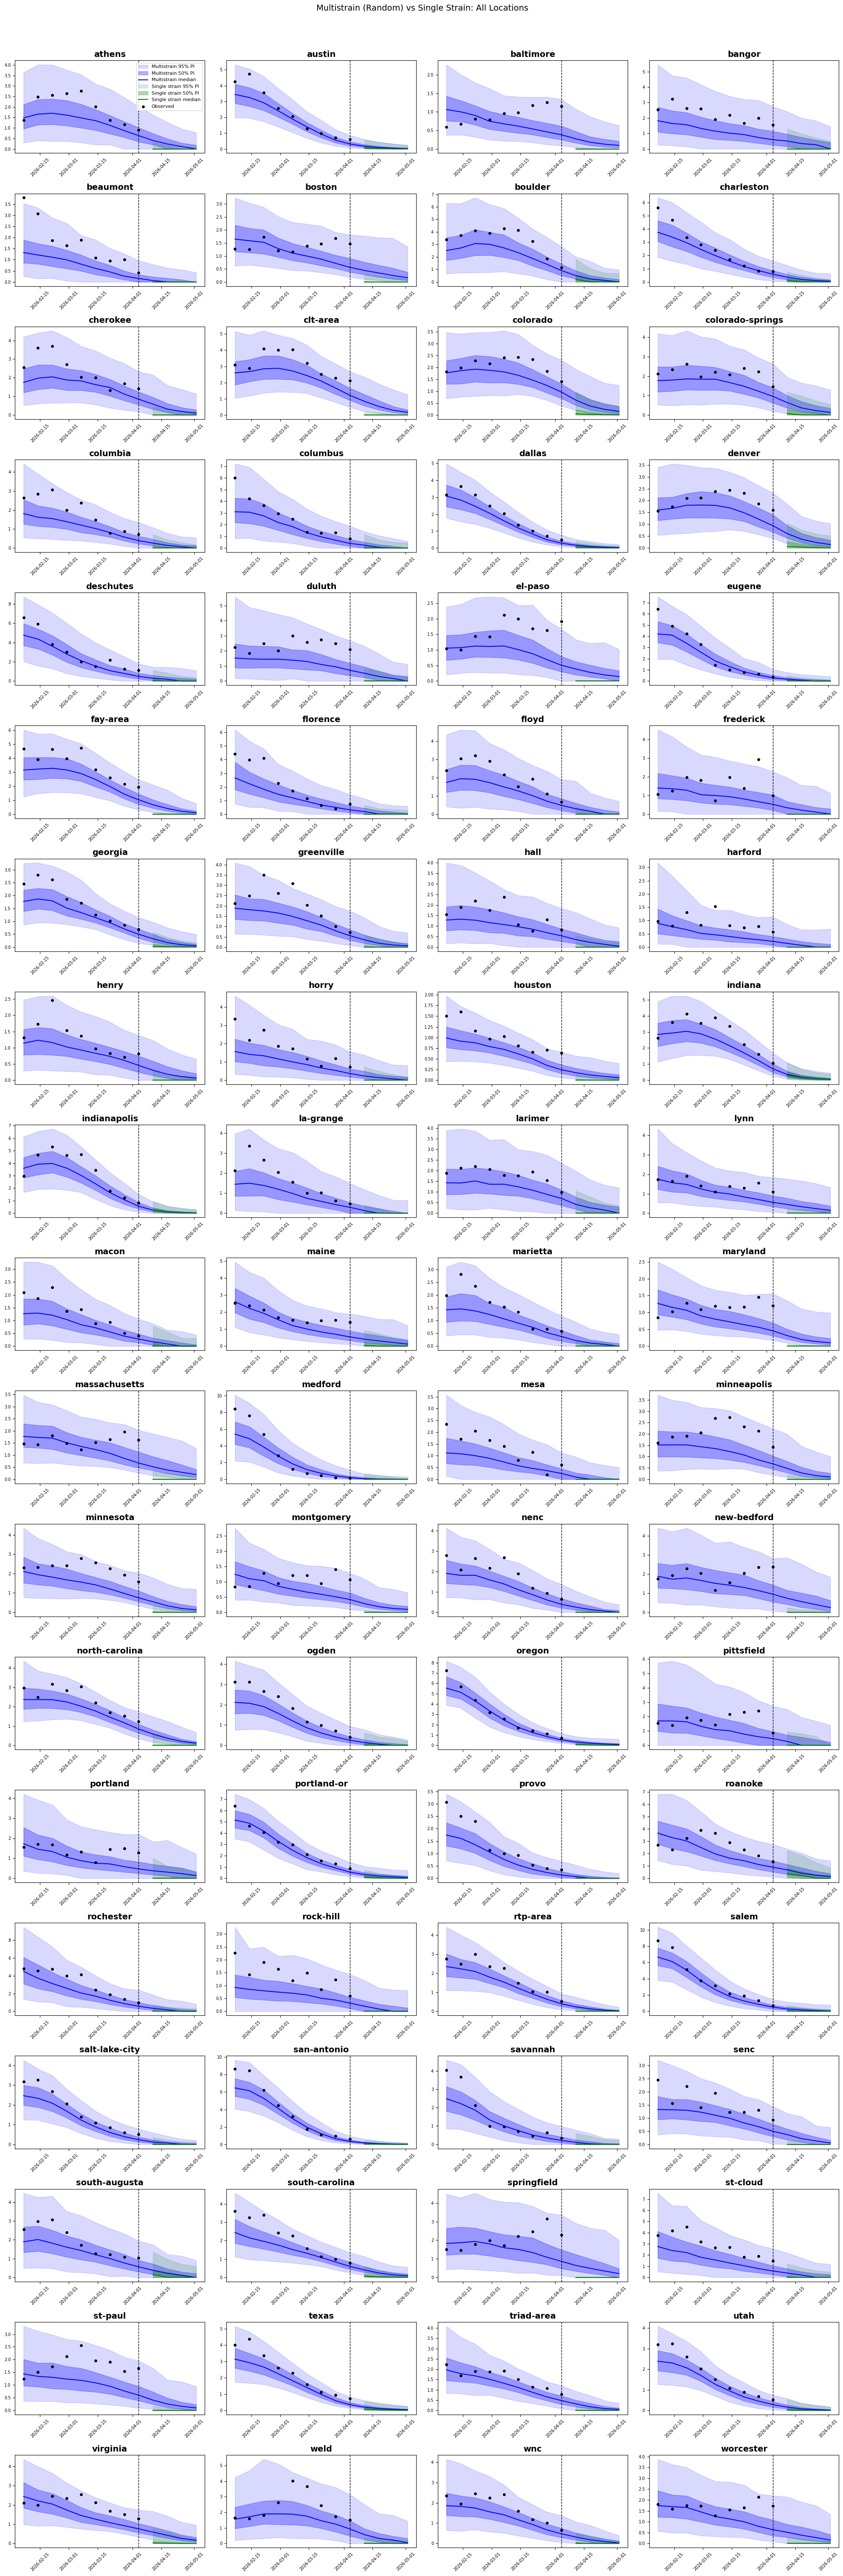

In [8]:
FILTER_PLOT = True

if FILTER_PLOT:
    plot_start_date = '2026-02-01'
    plot_prefix = 'filtered_'
else:
    plot_start_date = '2025-10-01'
    plot_prefix = ''

random_quantiles_filter =random_quantiles[(random_quantiles['date'] >= pd.to_datetime(plot_start_date)) & (random_quantiles['date'] < pd.to_datetime(final_date))]

fit_surv_data_filter = fit_surv_data[(fit_surv_data['date'] >= pd.to_datetime(plot_start_date)) & (fit_surv_data['date'] < pd.to_datetime(final_date))]

# Convert df_single to wide format for plotting (matching random_quantiles format)
df_single_quantiles = df_single[df_single['output_type'] == 'quantile'].copy()
df_single_quantiles['target_end_date'] = pd.to_datetime(df_single_quantiles['target_end_date'])

# Pivot to get quantile columns
df_single_wide = df_single_quantiles.pivot_table(
    index=['location', 'target_end_date'],
    columns='output_type_id',
    values='value'
).reset_index()

# Rename columns to match random_quantiles format
df_single_wide.columns.name = None
df_single_wide = df_single_wide.rename(columns={
    'target_end_date': 'date',
    '0.025': 'q025', '0.25': 'q250', '0.5': 'q500', '0.75': 'q750', '0.975': 'q975'
})

# Filter to date range
df_single_filter = df_single_wide[
    (df_single_wide['date'] >= pd.to_datetime(plot_start_date)) & 
    (df_single_wide['date'] < pd.to_datetime(final_date))
]

# Create 13x4 comparison figure: Random multistrain vs Single strain
fig, axes = plt.subplots(19, 4, figsize=(20, 60))
axes = axes.flatten()

for idx, pop in enumerate(populations):
    ax = axes[idx]
    location_name = pop.replace("metrocast_location_", "")
    
    # Get data for this population
    rand_pop = random_quantiles_filter[random_quantiles_filter['location'] == pop].sort_values('date')
    single_pop = df_single_filter[df_single_filter['location'] == location_name].sort_values('date')
    fit_surv_data_pop = fit_surv_data_filter[fit_surv_data_filter['location'] == location_name].sort_values('date')
    
    # Plot random multistrain sampling (blue)
    ax.fill_between(rand_pop['date'], rand_pop['q025'], rand_pop['q975'], 
                    alpha=0.15, color='blue', label='Multistrain 95% PI')
    ax.fill_between(rand_pop['date'], rand_pop['q250'], rand_pop['q750'], 
                    alpha=0.3, color='blue', label='Multistrain 50% PI')
    ax.plot(rand_pop['date'], rand_pop['q500'], 'b-', linewidth=1.5, label='Multistrain median')
    
    # Plot single strain (green)
    ax.fill_between(single_pop['date'], single_pop['q025'], single_pop['q975'], 
                    alpha=0.15, color='green', label='Single strain 95% PI')
    ax.fill_between(single_pop['date'], single_pop['q250'], single_pop['q750'], 
                    alpha=0.3, color='green', label='Single strain 50% PI')
    ax.plot(single_pop['date'], single_pop['q500'], 'g-', linewidth=1.5, label='Single strain median')
    
    # Plot ground truth (black markers)
    ax.scatter(fit_surv_data_pop['date'], fit_surv_data_pop['original_value'], 
               color='black', s=15, zorder=5, label='Observed')
    
    ax.set_title(location_name, fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', labelsize=7)
    ax.axvline(REFERENCE_DT - pd.Timedelta(weeks=1), color='black', linestyle='--', linewidth=1)
    
    # Only show legend for first subplot
    if idx == 0:
        ax.legend(fontsize=8, loc='upper right')

# Hide any unused subplots
for idx in range(len(populations), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Multistrain (Random) vs Single Strain: All Locations', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'../experiments/multistrain/{SUBMISSION_WEEK}-{TARGET}/multi_{TARGET}_smc_{DIST_FUNC}_{WINDOW}_{STRAINS}/{plot_prefix}multi_{TARGET}_smc_{DIST_FUNC}_{WINDOW}_{STRAINS}_multistrain_vs_single_comparison.pdf', 
            dpi=150, bbox_inches='tight')
plt.show()

## Submission File

In [9]:
# Create complete submission
submission = create_metro_submission(
    trajectories_df=random_combined,
    reference_date=REFERENCE_DATE,
    quantiles=get_metrocast_quantiles(),
    horizons=get_metrocast_horizons(),
    value_col='target_total'
)

print(f"Submission shape: {submission.shape}")
print(f"\nColumns: {submission.columns.tolist()}")
print(f"\nTargets: {submission['target'].unique()}")
print(f"Output types: {submission['output_type'].unique()}")
print(f"Horizons: {sorted(submission['horizon'].unique())}")
print(f"Locations: {submission['location'].nunique()}")
print(f"\nRows per target:")
print(submission.groupby(['target', 'output_type']).size())

Submission shape: (2736, 8)

Columns: ['reference_date', 'horizon', 'target_end_date', 'location', 'target', 'output_type', 'output_type_id', 'value']

Targets: <StringArray>
['Flu ED visits pct']
Length: 1, dtype: str
Output types: <StringArray>
['quantile']
Length: 1, dtype: str
Horizons: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Locations: 76

Rows per target:
target             output_type
Flu ED visits pct  quantile       2736
dtype: int64


In [10]:
submission

,reference_date,horizon,target_end_date,location,target,output_type,output_type_id,value
0,2026-04-11,0,2026-04-11,athens,Flu ED visits pct,quantile,0.025,0.000
1,2026-04-11,0,2026-04-11,athens,Flu ED visits pct,quantile,0.05,0.000
2,2026-04-11,0,2026-04-11,athens,Flu ED visits pct,quantile,0.1,0.000
3,2026-04-11,0,2026-04-11,athens,Flu ED visits pct,quantile,0.25,0.199
4,2026-04-11,0,2026-04-11,athens,Flu ED visits pct,quantile,0.5,0.399
...,...,...,...,...,...,...,...,...
2731,2026-04-11,3,2026-05-02,worcester,Flu ED visits pct,quantile,0.5,0.158
2732,2026-04-11,3,2026-05-02,worcester,Flu ED visits pct,quantile,0.75,0.409
2733,2026-04-11,3,2026-05-02,worcester,Flu ED visits pct,quantile,0.9,0.806
2734,2026-04-11,3,2026-05-02,worcester,Flu ED visits pct,quantile,0.95,1.094


In [11]:
submission.to_csv(f"../experiments/multistrain/{SUBMISSION_WEEK}-{TARGET}/multi_{TARGET}_smc_{DIST_FUNC}_{WINDOW}_{STRAINS}/{REFERENCE_DATE}-MOBS-EpyStrain_Flu.csv",
                  index=False)